# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

In [3]:
pokemon = pd.read_csv(fp, sep=",")

In [ ]:
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [5]:
pokemon.tail()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True
799,721,Volcanion,Fire,Water,600,80,110,120,130,90,70,6,True


## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

Text(0.5, 1.0, 'Attack vs Defense in Pokemons')

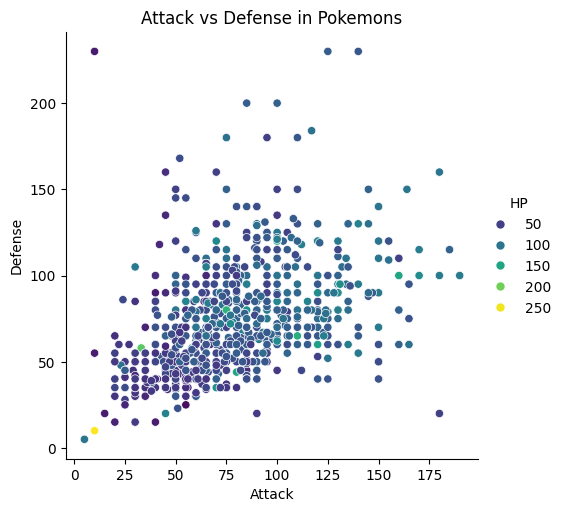

In [ ]:
sns.relplot(data=pokemon, x="Attack", y="Defense", hue="HP", palette="viridis")
plt.title("Attack vs Defense in Pokemons")

Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values. There is one point with the highest `HP` at very low values for `Attack` and `Defense`.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

Text(0.5, 1.05, 'Attack vs Total for all Pokemon')

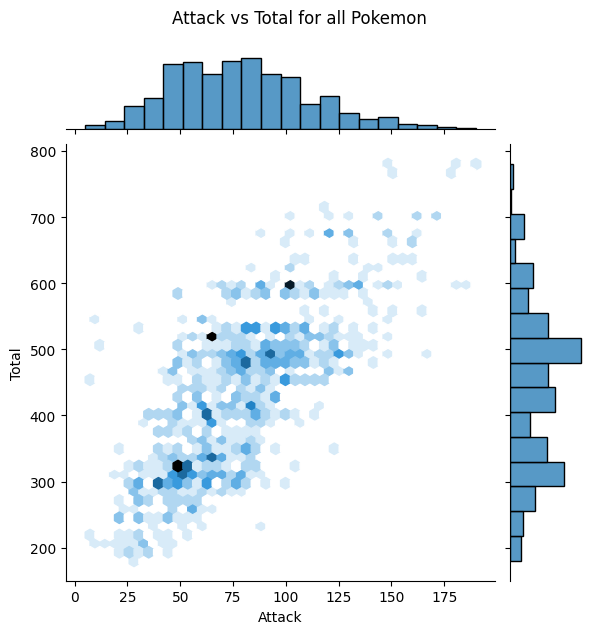

In [ ]:
sns.jointplot(data=pokemon, x="Attack", y="Total", kind="hex", gridsize=40)
plt.suptitle("Attack vs Total for all Pokemon", y=1.05)

Results: There is a positive correlation between `Attack` and `Total`. There is a concentration of Pokemon around 50-100 in `Attack` and 300-500 in `Total` showing that Pokemon with high stats are very rare.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

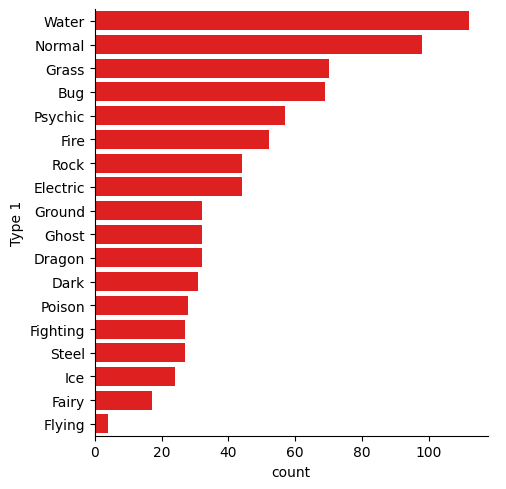

In [11]:
sns.catplot(
    data=pokemon,
    y="Type 1",
    kind='count',
    color='red',
    order = pokemon['Type 1'].value_counts().index,

)

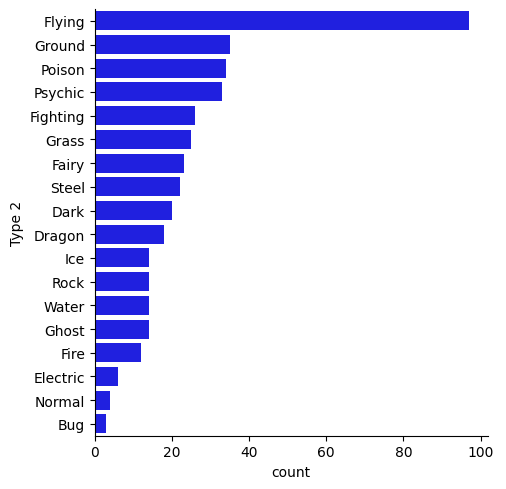

In [9]:
sns.catplot(
    data=pokemon,
    y="Type 2",
    kind='count',
    color='blue',
    order = pokemon['Type 2'].value_counts().index,

)

Results: The most common `Type 1` pokemon are water and normal pokemon. The most rare `Type 1` pokemon are fairy and flying pokemon.

The most common `Type 2` pokemon are flying and ground pokemon. The most rare `Type 2` pokemon are normal and bug pokemon.

## Q4: Plot the relationship between speed and HP

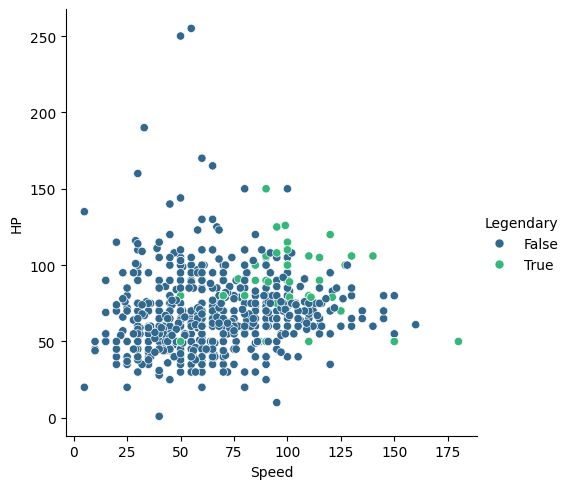

In [20]:
sns.relplot(
    data=pokemon,
    x="Speed",
    y='HP',
    hue="Legendary",
    palette="viridis"

)

Results: There is a weak positive relationship between `Speed` and `HP`. Legendary pokemon appear at higher `Speed` and somewhat higher `HP`. There is a lot of overlap between both groups.

## Q5: Categorical plots for Pokemon Types including Legendary status

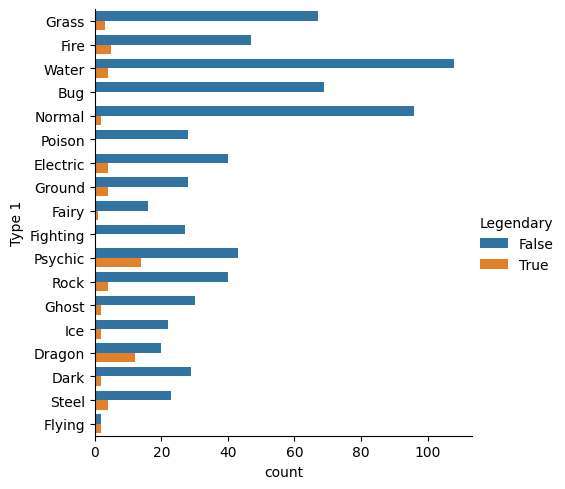

In [43]:
sns.catplot(
    data=pokemon,
    y='Type 1',
    hue='Legendary',
    kind='count'
)

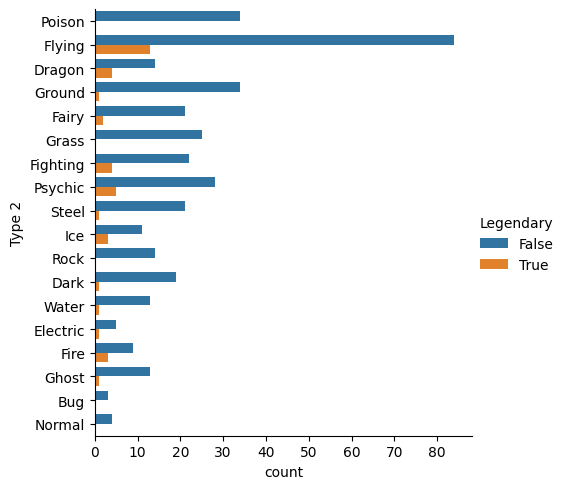

In [39]:
sns.catplot(
    data=pokemon,
    y='Type 2',
    hue='Legendary',
    kind='count'
)

Results: The amount of `Legendary` Pokemon is very low. `Legendary` Pokemon tend to have a primary type of Psychic and Dragon. `Legendary` Pokemon tend to have the secondary type of Flying and Psychic. The most common types of pokemon are not necessarily also legendary.

## Q6: Plot the relationship between Attack and Defense using a hexbin plot

Text(0.5, 1.05, 'Attack vs Defense for all Pokemon')

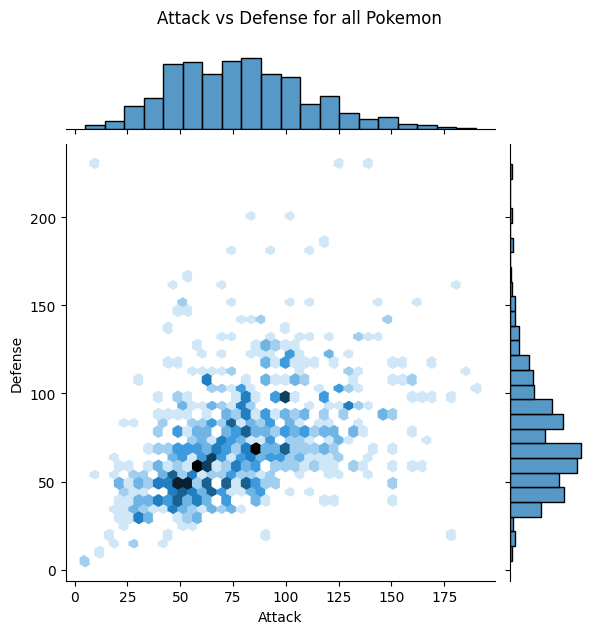

In [45]:
sns.jointplot(data=pokemon, x="Attack", y="Defense", kind="hex", gridsize=40)
plt.suptitle("Attack vs Defense for all Pokemon", y=1.05)

Results: There is a correlation between `Attack` and `Defense`. Most Pokemon appear in approximately 50-80 for `Attack` and 40-70 for `Defense`. Most Pokemon have mid-range stats.